In [ ]:
import pandas as pd
df = pd.read_csv("한국전력공사_전기차충전소위경도_시도.csv", encoding="cp949")
print('='*60)
print("행/열 개수:", df.shape)
print("열 이름:", list(df.columns))
print('='*60)
print(df.head())
print('='*60)
print(df.dtypes)

행/열 개수: (4673, 5)
열 이름: ['충전소 아이디', '충전소명', '시도', '위도', '경도']
   충전소 아이디             충전소명                     시도         위도          경도
0     8119         서울직할(공용)       서울특별시 중구 남대문로 92  37.565199  126.983339
1     8118      서울전력관리처(공용)   서울특별시 중구 남산동3가 11-10  37.560733  126.987796
2     5631          버티공영주차장  서울특별시 중구 신당동 432-1693  37.549063  127.006247
3     5167         SK렌터카 본사      서울특별시 종로구 관철동 7-3  37.569474  126.987209
4     5063  서울대학교병원 암병동 주차장    서울특별시 종로구 연건동 28-21  37.578789  126.997606
충전소 아이디      int64
충전소명        object
시도          object
위도         float64
경도         float64
dtype: object


In [ ]:
print("\n[지역별 충전소 수]")
print(df["시도"].value_counts())

print("\n[현재 데이터에 들어 있는 지역명]")
print(df["시도"].unique())

print("\n[지역명의 종류는 몇 개인가?]")
print(df["시도"].nunique())


[지역별 충전소 수]
시도
전북특별자치도 익산시 팔봉동 850       4
서울 성동구 하왕십리동 1070         4
광주광역시 광산구 우산동 1611-1      4
서울특별시 마포구 아현동 마포대로 195    4
광주광역시 광산구 산정동 974-1       4
                         ..
경기도 하남시 선동 423            1
경기도 하남시 학암동 662           1
경기도 하남시 풍산동 480           1
경기도 하남시 망월동 949           1
경기도 하남시 풍산동 477           1
Name: count, Length: 4434, dtype: int64

[현재 데이터에 들어 있는 지역명]
['서울특별시 중구 남대문로 92' '서울특별시 중구 남산동3가 11-10' '서울특별시 중구 신당동 432-1693' ...
 '제주특별자치도 서귀포시 성산읍 수산리 703-1' '제주특별자치도 서귀포시 동홍동 1530-2'
 '제주특별자치도 서귀포시 성산읍 난산리 1108']

[지역명의 종류는 몇 개인가?]
4434


결측치 즉 비어 있는 행이 있는 지를 먼저 확인

In [ ]:
print(df["시도"].isna().sum()) #결측치의 개수를 확인해보자

0


In [ ]:
print(df[df["시도"].isna()].index) #비어있는 행이 있는지,,결측치를 확인해보자

Index([], dtype='int64')


In [ ]:
#df = df.drop(10) #만약 인덱스가 10번인 걸 확인하면 이렇게 삭제하면 됨
#print(df.loc[10])

In [ ]:
'''
# 시도 열에 결측치가 있는 행 확인
print(df[df["시도"].isna()])

# 시도 열의 결측치가 있는 행 삭제
df = df.dropna(subset=["시도"])

# 확인
print(df["시도"].isna().sum())
'''
#이렇게 하면 한번에 시도열의 결측치 행을 제거하고, 제거한 후 0의 결과를 확인할 수 있다.

'\n# 시도 열에 결측치가 있는 행 확인\nprint(df[df["시도"].isna()])\n\n# 시도 열의 결측치가 있는 행 삭제\ndf = df.dropna(subset=["시도"])\n\n# 확인\nprint(df["시도"].isna().sum())\n'

중복된 행이 있는 지를 2번째로 확인

In [ ]:
print(df.duplicated().any()) #False이면 중복된 행이 없다, True는 중복된 행이 있다.

False


In [ ]:
'''
print(df.duplicated().sum()) #중복된 행의 갯수를 파악
print(df[df.duplicated()]) #중복된 행을 출력
print(df[df.duplicated()].index) #중복된 행의 인덱스를 파악
df = df.drop_duplicates() #10, 25, 37의 경우 10번 행을 남기고 나머지 행은 제거
df.drop_duplicates(keep="first") #기본적으로 첫번째를 남기기는 하지만
'''

'\nprint(df.duplicated().sum()) #중복된 행의 갯수를 파악\nprint(df[df.duplicated()]) #중복된 행을 출력\nprint(df[df.duplicated()].index) #중복된 행의 인덱스를 파악\ndf = df.drop_duplicates() #10, 25, 37의 경우 10번 행을 남기고 나머지 행은 제거\ndf.drop_duplicates(keep="first") #기본적으로 첫번째를 남기기는 하지만\n'

In [ ]:
print(df["시도"].head())
print("서로 다른 값 개수:", df["시도"].nunique())
print("주소 첫 단어(=시도명) 종류별 개수:")
print(df["시도"].str.split().str[0].value_counts())

0         서울특별시 중구 남대문로 92
1     서울특별시 중구 남산동3가 11-10
2    서울특별시 중구 신당동 432-1693
3        서울특별시 종로구 관철동 7-3
4      서울특별시 종로구 연건동 28-21
Name: 시도, dtype: object
서로 다른 값 개수: 4434
주소 첫 단어(=시도명) 종류별 개수:
시도
경기도        846
서울특별시      572
경상남도       435
경상북도       389
전라남도       273
강원특별자치도    266
대구광역시      218
제주특별자치도    218
충청남도       217
전북특별자치도    212
충청북도       210
부산광역시      191
인천광역시      187
대전광역시      131
광주광역시      123
세종특별자치시     73
울산광역시       60
서울          10
경북           9
경기           5
경남           5
전남           5
충북           4
부산           3
인천           3
충남           3
대전           2
광주           1
대구           1
울산           1
Name: count, dtype: int64


In [ ]:
!pip install koreanize-matplotlib

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

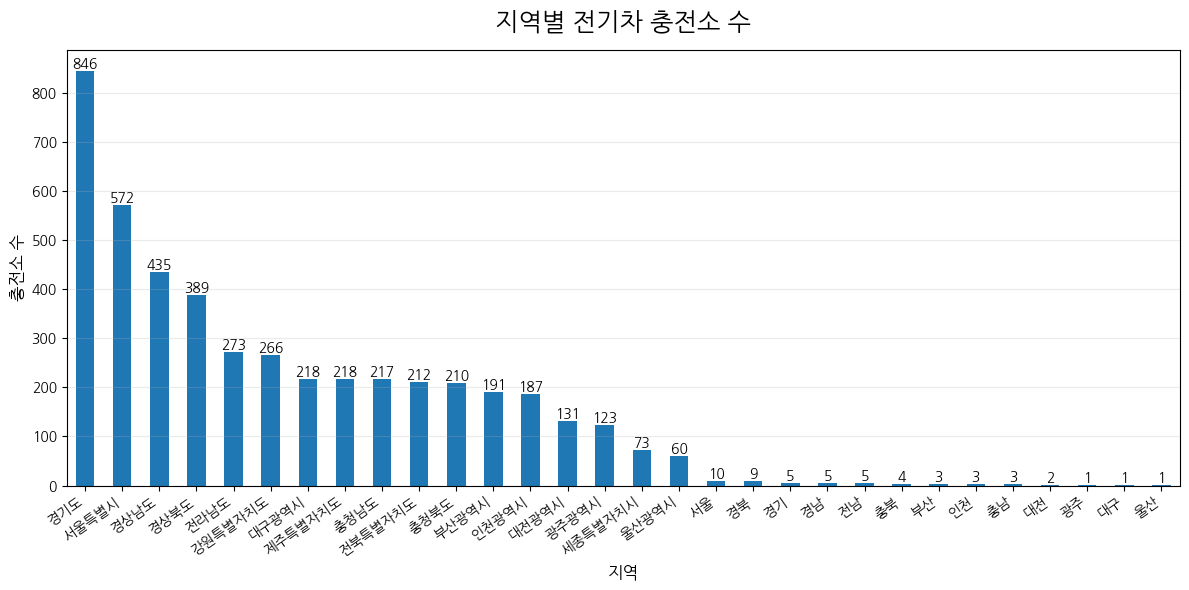

In [ ]:
지역별_개수 = df["시도"].str.split().str[0].value_counts()

plt.figure(figsize=(12, 6))

ax = 지역별_개수.plot(kind="bar")

plt.title("지역별 전기차 충전소 수", fontsize=18, pad=15)
plt.xlabel("지역", fontsize=12)
plt.ylabel("충전소 수", fontsize=12)

# 지역명을 약간 기울여 표시
plt.xticks(rotation=35, ha="right")

# 가로 격자
plt.grid(axis="y", alpha=0.25)

# 막대 위에 숫자 표시
for i, value in enumerate(지역별_개수): #지역별_개수를 하나씩 거내면서 x위치, y위치에 해당하는 글자를 표시-첫번째 (0,846)의 좌표에 846을 기록
    plt.text(i, value, str(value),
             ha="center", va="bottom", fontsize=10)
# ha-horizotal alignment (가로 방향 가운데 정렬), va-vertical alignment (세로 방향에서 글자의 아래쪽 기준으로 배치)
plt.tight_layout()
plt.show()

전처리----중요

In [ ]:
# 열 이름 정리 + 주소에서 시도명 뽑기
df = df.rename(columns={"시도": "주소"})
df["시도명"] = df["주소"].str.split().str[0]

# 시도명 표기 통일
시도_표준화 = {
    "서울": "서울특별시", "부산": "부산광역시", "대구": "대구광역시",
    "인천": "인천광역시", "대전": "대전광역시",
    "울산": "울산광역시", "세종": "세종특별자치시",
    "경기": "경기도",
    "강원": "강원특별자치도", "강원도": "강원특별자치도",
    "충북": "충청북도", "충남": "충청남도",
    "전북": "전북특별자치도", "전라북도": "전북특별자치도",
    "전남": "전남광주특별시",  "광주": "전남광주특별시", "광주광역시": "전남광주특별시", "전라남도": "전남광주특별시",
    "경북": "경상북도", "경남": "경상남도",
    "제주": "제주특별자치도", "제주도": "제주특별자치도",
}
df["시도명"] = df["시도명"].replace(시도_표준화)

# 열 순서 정리
df = df[["충전소 아이디", "충전소명", "시도명", "주소", "위도", "경도"]]
df

,충전소 아이디,충전소명,시도명,주소,위도,경도
0,8119,서울직할(공용),서울특별시,서울특별시 중구 남대문로 92,37.565199,126.983339
1,8118,서울전력관리처(공용),서울특별시,서울특별시 중구 남산동3가 11-10,37.560733,126.987796
2,5631,버티공영주차장,서울특별시,서울특별시 중구 신당동 432-1693,37.549063,127.006247
3,5167,SK렌터카 본사,서울특별시,서울특별시 종로구 관철동 7-3,37.569474,126.987209
4,5063,서울대학교병원 암병동 주차장,서울특별시,서울특별시 종로구 연건동 28-21,37.578789,126.997606
...,...,...,...,...,...,...
4668,385,정방폭포,제주특별자치도,제주특별자치도 서귀포시 동홍동278,33.245004,126.573164
4669,384,수산1리 복지회관,제주특별자치도,제주특별자치도 서귀포시 성산읍 수산리 703-1,33.446088,126.883146
4670,383,서귀포의료원,제주특별자치도,제주특별자치도 서귀포시 동홍동 1530-2,33.256230,126.564014
4671,382,난산리 다목적회관,제주특별자치도,제주특별자치도 서귀포시 성산읍 난산리 1108,33.401291,126.870952


In [ ]:
'''
서울시 강남구 테헤란로 100
시도.split()
["서울시", "강남구", "테헤란로", "100"]
시도.split()[0]
'''

'\n서울시 강남구 테헤란로 100\n시도.split()\n["서울시", "강남구", "테헤란로", "100"]\n시도.split()[0]\n'

그래프를 그려보자,, 지역별 충전소는 몇개가 있을까?

In [ ]:
!pip install koreanize-matplotlib

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

지역별_개수: 16
지역별_개수: 시도명
경기도        851
서울특별시      582
경상남도       440
전남광주특별시    402
경상북도       398
강원특별자치도    266
충청남도       220
대구광역시      219
제주특별자치도    218
충청북도       214
전북특별자치도    212
부산광역시      194
인천광역시      190
대전광역시      133
세종특별자치시     73
울산광역시       61
Name: count, dtype: int64


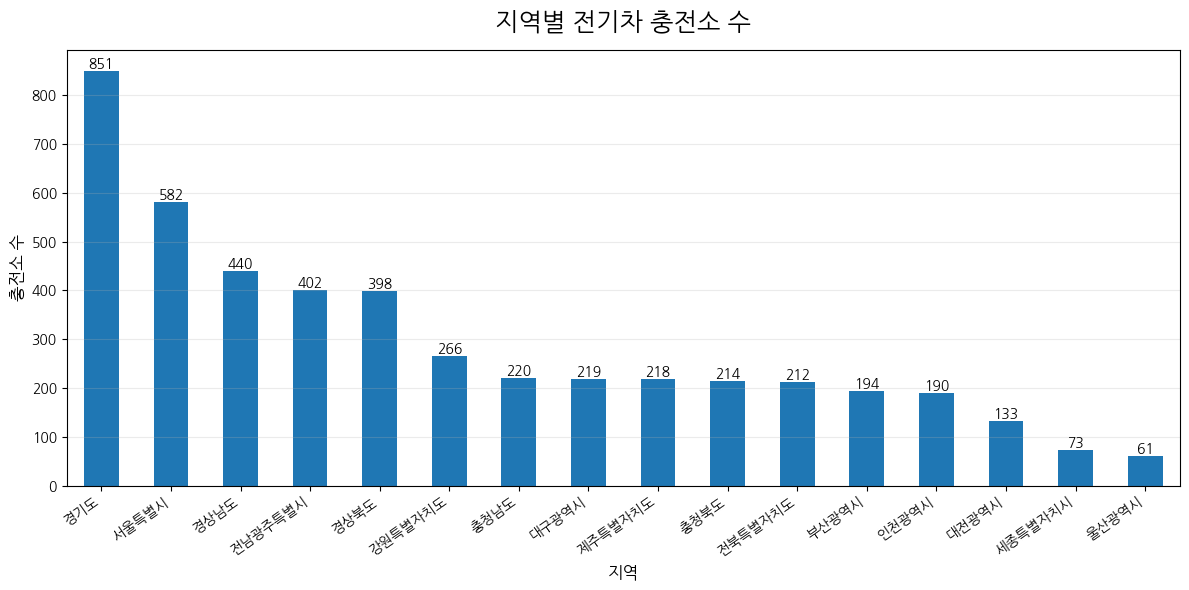

In [ ]:
지역별_개수 = df["시도명"].value_counts()
print('지역별_개수:', len(지역별_개수))
print('지역별_개수:', 지역별_개수)
print('='*60)
plt.figure(figsize=(12, 6))

ax = 지역별_개수.plot(kind="bar")

plt.title("지역별 전기차 충전소 수", fontsize=18, pad=15)
plt.xlabel("지역", fontsize=12)
plt.ylabel("충전소 수", fontsize=12)

# 지역명을 약간 기울여 표시
plt.xticks(rotation=35, ha="right")

# 가로 격자
plt.grid(axis="y", alpha=0.25)

# 막대 위에 숫자 표시
for i, value in enumerate(지역별_개수):
    plt.text(i, value, str(value),
             ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# 전처리한 데이터프레임을 CSV 파일로 저장
df.to_csv("지역충전소_전처리완료.csv", index=False, encoding="utf-8-sig")

# 내 컴퓨터로 다운로드
from google.colab import files
files.download("지역충전소_전처리완료.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

위도와 경도로 시각화

In [ ]:
!pip install koreanize-matplotlib

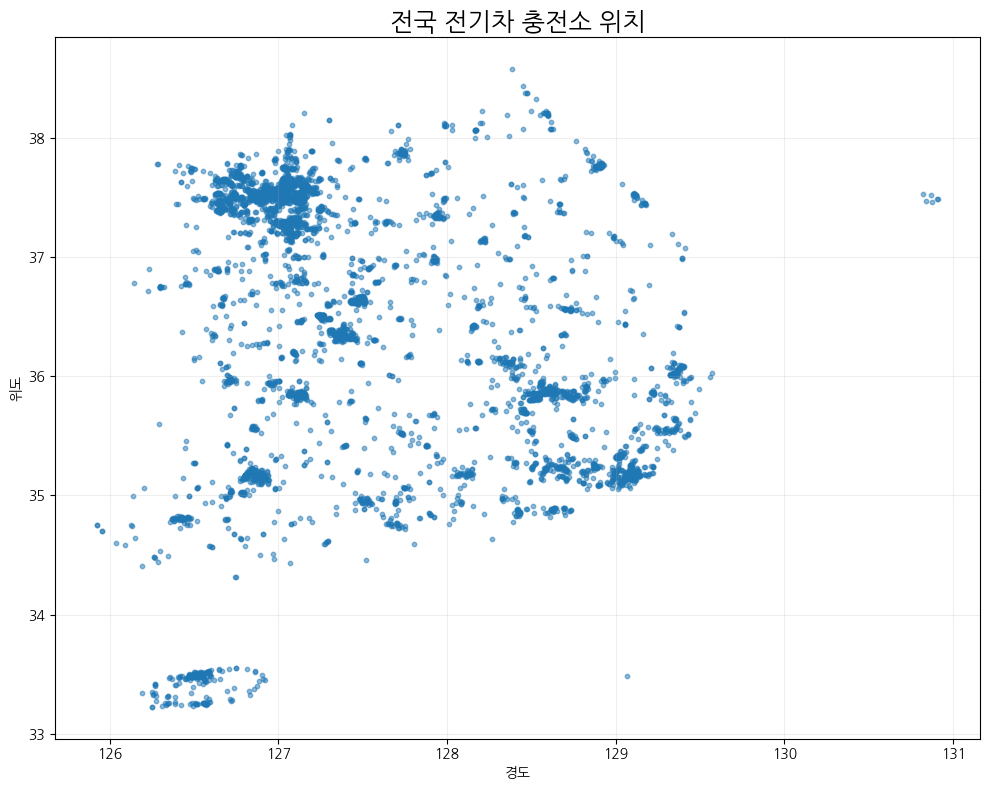

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.figure(figsize=(10, 8))

plt.scatter(
    df["경도"],
    df["위도"],
    s=10,
    alpha=0.5
)

plt.title("전국 전기차 충전소 위치", fontsize=18)
plt.xlabel("경도")
plt.ylabel("위도")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

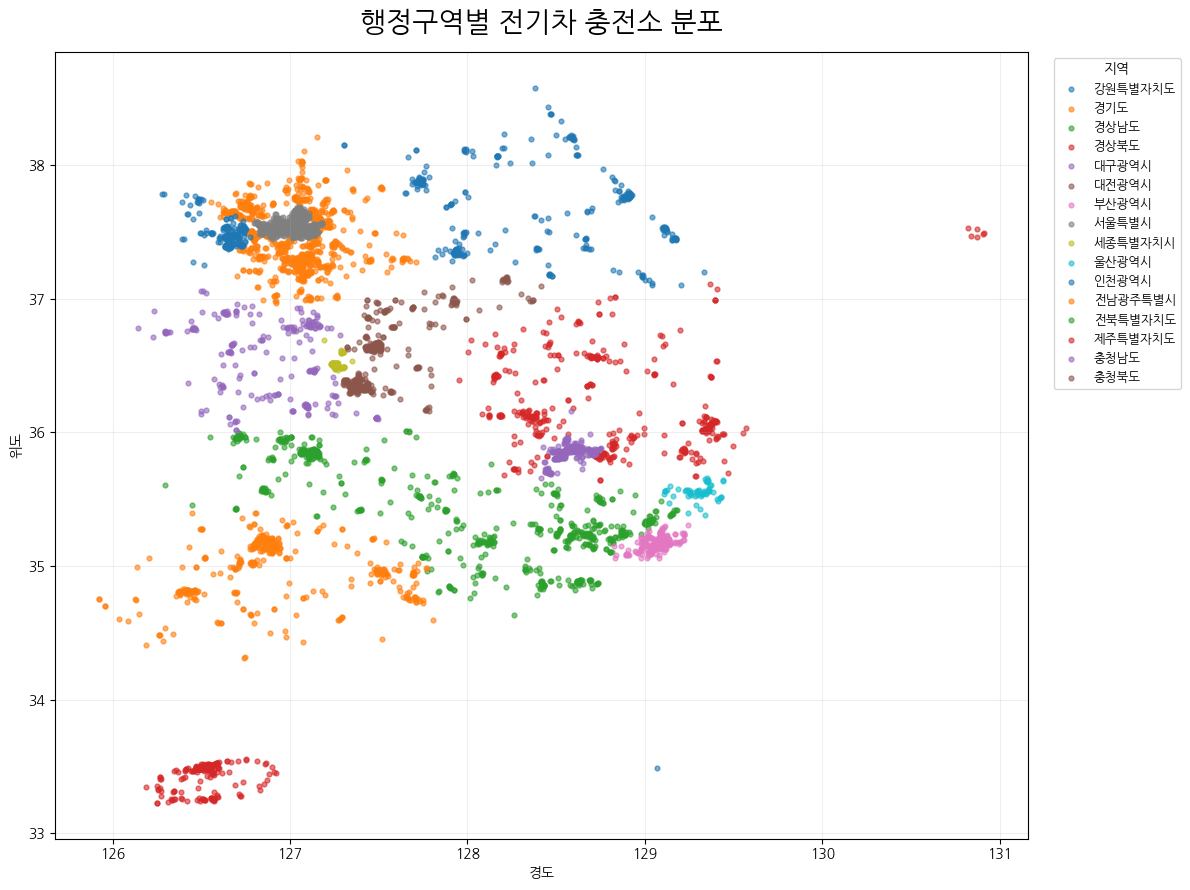

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.figure(figsize=(12, 9))

# 지역별로 색을 다르게 표시
for 지역, 데이터 in df.groupby("시도명"):

    plt.scatter(
        데이터["경도"],
        데이터["위도"],
        s=12,
        alpha=0.6,
        label=지역
    )

plt.title("행정구역별 전기차 충전소 분포", fontsize=20, pad=15)
plt.xlabel("경도")
plt.ylabel("위도")

plt.grid(alpha=0.2)

# 지역 이름 표시
plt.legend(
    title="지역",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9
)

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

위치데이터 = df.dropna(subset=["위도", "경도"])

fig = px.scatter(
    위치데이터,
    x="경도",
    y="위도",
    color="시도명",
    hover_name="시도명",
    hover_data=["위도", "경도"],
    title="행정구역별 전기차 충전소 위치"
)

fig.update_traces(
    marker=dict(
        size=7,
        opacity=0.6
    )
)

fig.update_layout(
    width=900,
    height=900,
    xaxis_title="경도",
    yaxis_title="위도"
)

# 가로·세로 축의 실제 비율을 동일하게 유지
fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1
)

fig.show()

이상치 여부 확인

In [ ]:
print(df[df["시도명"] == "강원특별자치도"]) #강원도로 분류된 행 전체가 출력됨

      충전소 아이디            충전소명      시도명                          주소         위도  \
1623     8026        강원직할(공용)  강원특별자치도          강원특별자치도 춘천시 후평동 95  37.883416   
1624     6756        강원국악예술회관  강원특별자치도         강원특별자치도 춘천시 삼천동 200  37.872183   
1625     5771           강원혈액원  강원특별자치도       강원특별자치도 춘천시 퇴계동 862-3  37.845784   
1626     5628           강원대학교  강원특별자치도       강원특별자치도 춘천시 효자동 192-1  37.872568   
1627     5509         국립춘천숲체원  강원특별자치도  강원특별자치도 춘천시 신북읍 발산리 산 32-1  37.991739   
...       ...             ...      ...                         ...        ...   
1884     3725        횡성국민체육센터  강원특별자치도     강원특별자치도 횡성군 횡성읍 읍하리 260  37.490760   
1885     3719           먹거리단지  강원특별자치도   강원특별자치도 횡성군 횡성읍 곡교리 128-2  37.460533   
1886     1049        원흥2차 아파트  강원특별자치도   강원특별자치도 횡성군 횡성읍 읍하리 395-2  37.495313   
1887      846       대동황토방 아파트  강원특별자치도     강원특별자치도 횡성군 횡성읍 읍하리 518  37.493891   
1888      326  횡성지사 전기차 충전소 1  강원특별자치도   강원특별자치도 횡성군 횡성읍 읍하리 561-7  37.488949   

              경도  
1623  12

In [ ]:
print(df.loc[df["시도명"] == "강원특별자치도", ["시도명", "위도", "경도"]])

          시도명         위도          경도
1623  강원특별자치도  37.883416  127.750565
1624  강원특별자치도  37.872183  127.701329
1625  강원특별자치도  37.845784  127.735965
1626  강원특별자치도  37.872568  127.741690
1627  강원특별자치도  37.991739  127.767741
...       ...        ...         ...
1884  강원특별자치도  37.490760  127.977921
1885  강원특별자치도  37.460533  127.974726
1886  강원특별자치도  37.495313  127.983546
1887  강원특별자치도  37.493891  127.987038
1888  강원특별자치도  37.488949  127.982804

[265 rows x 3 columns]


In [ ]:
print(df.loc[
    (df["시도명"] == "강원특별자치도") &
    (df["위도"] == 33.48848)
].index)

Index([], dtype='int64')


In [ ]:
result = df[
    (df["시도명"] == "강원특별자치도") &
    (df["위도"].between(33.48, 33.50))
]

print(result)

Empty DataFrame
Columns: [충전소 아이디, 충전소명, 시도명, 주소, 위도, 경도]
Index: []


In [ ]:
#df=df.drop(1707)
df = df[
    ~(
        (df["시도명"] == "강원특별자치도") &
        (df["위도"] == 33.48848)
    )
]
'''
이상치를 발견했다고 무조건 삭제하는 것이 아니라,
좌표와 실제 위치를 확인한 결과 오류임을 확인했기 때문에 제거한다.
'''

'\n이상치를 발견했다고 무조건 삭제하는 것이 아니라,\n좌표와 실제 위치를 확인한 결과 오류임을 확인했기 때문에 제거한다.\n'

In [ ]:
print(len(df.loc[
    (df["시도명"] == "강원특별자치도") &
    (df["위도"] == 33.48848)
]))

0


In [ ]:
import plotly.express as px

위치데이터 = df.dropna(subset=["위도", "경도"])

fig = px.scatter(
    위치데이터,
    x="경도",
    y="위도",
    color="시도명",
    hover_name="시도명",
    hover_data=["위도", "경도"],
    title="행정구역별 전기차 충전소 위치"
)

fig.update_traces(
    marker=dict(
        size=7,
        opacity=0.6
    )
)

fig.update_layout(
    width=900,
    height=900,
    xaxis_title="경도",
    yaxis_title="위도"
)

# 가로·세로 축의 실제 비율을 동일하게 유지
fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1
)

fig.show()